In [1]:
import numpy as np
from scipy.constants import h, c, k
from scipy.integrate import quad
from scipy.interpolate import interp1d
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import os
import datetime
import csv
from datetime import datetime

In [230]:
# === SETTINGS ===
ID = "A3"  # Station ID

# === File Paths ===
dir_path = Path.cwd()  # current working directory
print("Current working directory:", dir_path)

# Data directory 
data_dir = dir_path.parent / "data"
# Protocols directory 
protocol_dir = dir_path.parent / "protocols"
# Halobates data directory 
halobates_dir =  data_dir / "halobates_data"
# Results directory 
results_dir = dir_path.parent / "results"
# Raw SST temperature directory
out_dir = dir_path / "raw"
# Averaged SST temperature directory
out_dir_avg = dir_path / "1min"


# Halobates protocol file
protocol_file = sorted(protocol_dir.glob(f"*{ID}_17_CST_Schedule.csv"))
protocol_file  = str(protocol_file[0])

# SST temperature file 
sst_file = sorted(out_dir.glob(f"*{ID}_17_IR_SST.csv"))
sst_file  = str(sst_file[0])

# Halobates file
halobates_file = sorted(halobates_dir.glob(f"{ID}_Halobates.csv"))
halobates_file  = str(halobates_file[0])

# Output path for SST vs SML data
sst_sml_output_file = results_dir / "SST_vs_SML.csv"

# === Debug output (optional) ===
print("Halobates data file:", halobates_file)
print("Halobates protocol file:", protocol_file)

Current working directory: c:\Users\ludog\Nextcloud\CLEWS\work\METEOR\IR Camera\github\Infrared_cameras\postproc


IndexError: list index out of range

### Clip SST temperatures based on Halobates protocol

C:\Users\ludog\AppData\Local\Temp\ipykernel_14096\3148983502.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_halo = pd.read_csv(halobates_file, parse_dates=['Date_Time'])


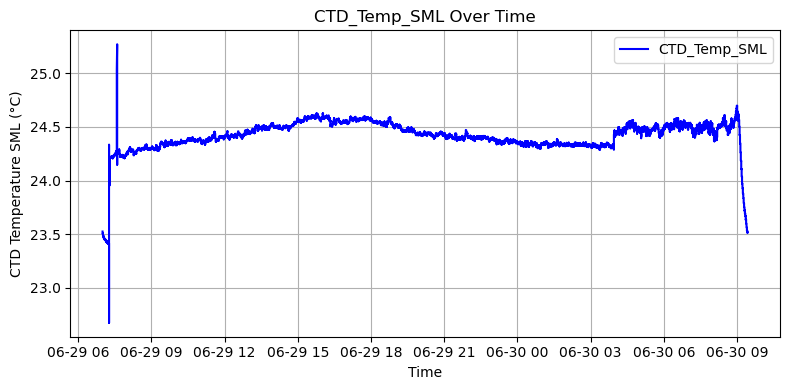

In [176]:
# Load Halobates data
df_halo = pd.read_csv(halobates_file, parse_dates=['Date_Time'])

# Rename time column for consistency    
df_halo  = df_halo.rename(columns={'Date_Time': 'Time'})

# Plot SML temperature 
plt.figure(figsize=(8, 4))
plt.plot(df_halo['Time'], df_halo['CTD_Temp_SML'], label='CTD_Temp_SML', color='blue')
plt.xlabel('Time')
plt.ylabel('CTD Temperature SML (°C)')
plt.title('CTD_Temp_SML Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [231]:
# Load Halobates protocol file
df_protocol = pd.read_csv(
    protocol_file,
    sep=';',
    parse_dates=['Start', 'End'],
    dayfirst=True
)

# Create a 'Type' column:
# – if 'Event' contains 'Deployment', mark as deployment
# – elif 'Event' contains 'Bridge', mark as bridge
# – else mark everything else as intervention
df_protocol['Type'] = np.where(
    df_protocol['Event'].str.contains('Deployment', case=False, na=False),
    'deployment',
    np.where(
        df_protocol['Event'].str.contains('Bridge', case=False, na=False),
        'bridge',
        'intervention'
    )
)

# Drop the original Event column
df_protocol = df_protocol[['Type', 'Start', 'End']]

print(df_protocol)


            Type               Start                 End
0     deployment 2025-07-02 07:48:00 2025-07-03 08:20:00
1         bridge 2025-07-02 07:48:00 2025-07-03 08:18:00
2   intervention 2025-07-02 08:04:00 2025-07-02 08:10:00
3   intervention 2025-07-02 08:59:00 2025-07-02 09:19:00
4   intervention 2025-07-02 10:20:00 2025-07-02 10:21:00
5   intervention 2025-07-02 19:09:00 2025-07-02 19:32:00
6     deployment 2025-07-03 11:00:00 2025-07-03 16:31:00
7         bridge 2025-07-03 11:10:00 2025-07-03 16:31:00
8   intervention 2025-07-03 11:36:00 2025-07-03 11:37:00
9   intervention 2025-07-03 14:35:00 2025-07-03 14:36:00
10  intervention 2025-07-03 15:28:00 2025-07-03 15:35:00
11  intervention 2025-07-03 16:25:00 2025-07-03 16:28:00
12    deployment 2025-07-03 20:15:00 2025-07-04 18:39:00
13        bridge 2025-07-03 20:16:00 2025-07-04 18:21:00
14  intervention 2025-07-04 17:47:00 2025-07-04 17:51:00


In [247]:
# Load SST data
df_sst = pd.read_csv(sst_file, parse_dates=['Time'])

df_sst.head()


,Time,SST (°C)
0,2025-07-02 07:15:03,25.510510
1,2025-07-02 07:15:04,25.511290
2,2025-07-02 07:15:05,26.036358
3,2025-07-02 07:15:06,26.349409
4,2025-07-02 07:15:07,25.852432


In [233]:
# Updated function to handle the cases of multiple deployments in the same station
# Masks all times within intervention periods and looks for ealy spiked within 5 minutes from the intervention starts

def compute_threshold(ts: pd.Series, start: pd.Timestamp, end: pd.Timestamp, num_std: float = 2) -> float:
    ref = ts[start:end]
    return ref.mean() + num_std * ref.std()

def clean_sst_multideploy(
    df_sst: pd.DataFrame,
    df_protocol: pd.DataFrame,
    sst_variable: str,
    shift_s: int = 300
) -> pd.DataFrame:
    # Timestamp‐index your SST
    df = df_sst.copy()
    df["Time"] = pd.to_datetime(df["Time"])
    df = df.set_index("Time").sort_index()
    ts = df[sst_variable]

    cleaned_segments = []

    # loop each deployment block
    for _, dep in df_protocol[df_protocol["Type"] == "deployment"].iterrows():
        dep_start, dep_end = dep["Start"], dep["End"]
        # find its bridge rows (there should be one per deployment)
        bridges = df_protocol[
            (df_protocol["Type"] == "bridge") &
            (df_protocol["Start"] >= dep_start) &
            (df_protocol["End"]   <= dep_end)
        ]
        # if no bridge, treat whole deployment as one segment
        if bridges.empty:
            segments = [(dep_start, dep_end)]
        else:
            segments = [(b["Start"], b["End"]) for _, b in bridges.iterrows()]

        # within each bridge segment, mask interventions
        for seg_start, seg_end in segments:
            segment = ts[seg_start:seg_end].copy()
            intervs = df_protocol[
                (df_protocol["Type"] == "intervention") &
                (df_protocol["Start"] >= seg_start) &
                (df_protocol["End"]   <= seg_end)
            ]
            for _, iv in intervs.iterrows():
                sched_start, sched_end = iv["Start"], iv["End"]
                baseline_start = sched_start - pd.Timedelta(seconds=shift_s)
                # compute threshold on clean baseline
                thresh = compute_threshold(segment, baseline_start, sched_start)
                # look back for early spikes
                pre = segment[baseline_start:sched_start]
                spikes = pre[pre > thresh]
                actual_start = spikes.index.min() if not spikes.empty else sched_start
                # mask the full intervention interval
                segment.loc[actual_start:sched_end] = np.nan
            cleaned_segments.append(segment)
    # concatenate all cleaned bridge blocks
    if cleaned_segments:
        cleaned = pd.concat(cleaned_segments).sort_index()
    else:
        cleaned = pd.Series(dtype=float, name=sst_variable)

    return cleaned.reset_index(name=sst_variable)

In [ ]:
# ALTERNATIVE: 
# Function to compute anomaly threshold based on mean and standard deviation of the data before the intervention
# Handles multiple deployments and bridges, masking interventions only if SST values exceed a data-driven threshold.

def compute_threshold(ts: pd.Series, start: pd.Timestamp, end: pd.Timestamp, num_std: float = 2) -> float:
    """
    Compute anomaly threshold = mean + num_std * std of ts between start and end.
    """
    ref = ts[start:end]
    return ref.mean() + num_std * ref.std()


def clean_sst_multideploy(
    df_sst: pd.DataFrame,
    df_protocol: pd.DataFrame,
    sst_variable: str,
    shift_s: int = 300
) -> pd.DataFrame:
    """
    Clean SST across multiple deployments and bridge windows:
      - df_protocol must have a 'Type' column with values:
          'deployment', 'bridge', 'intervention'.
      - Data is clipped to each deployment and nested bridge window.
      - Within each bridge, scheduled interventions are masked 
        *only* for SST values above a data-driven threshold.

    Returns:
        DataFrame with ['Time', sst_variable] concatenated for all valid segments.
    """
    # Prepare SST series
    df = df_sst.copy()
    df['Time'] = pd.to_datetime(df['Time'])
    df = df.set_index('Time').sort_index()
    ts = df[sst_variable]

    # Prepare protocol
    proto = df_protocol.copy()
    proto['Start'] = pd.to_datetime(proto['Start'])
    proto['End']   = pd.to_datetime(proto['End'])

    cleaned_segments = []

    # Loop through deployments
    for _, dep in proto[proto['Type']=='deployment'].iterrows():
        dep_start, dep_end = dep['Start'], dep['End']
        # Find all bridge intervals within this deployment
        bridges = proto[(proto['Type']=='bridge') &
                        (proto['Start'] >= dep_start) &
                        (proto['End']   <= dep_end)]

        # If no explicit bridge rows, use the full deployment
        segments = [(row['Start'], row['End']) for _, row in bridges.iterrows()] or [(dep_start, dep_end)]

        # Process each segment: clip and selectively mask interventions
        for seg_start, seg_end in segments:
            segment = ts[seg_start:seg_end].copy()
            # Find interventions within this segment
            intervs = proto[(proto['Type']=='intervention') &
                            (proto['Start'] >= seg_start) &
                            (proto['End']   <= seg_end)]
            for _, iv in intervs.iterrows():
                sched_start, sched_end = iv['Start'], iv['End']
                # Baseline window for threshold: [sched_start - shift_s, sched_start]
                baseline_start = sched_start - pd.Timedelta(seconds=shift_s)
                threshold = compute_threshold(segment, baseline_start, sched_start)
                # Mask only values above threshold in the scheduled window
                mask = (segment.index >= sched_start) & \
                       (segment.index <= sched_end) & \
                       (segment > threshold)
                segment.loc[mask] = np.nan

            cleaned_segments.append(segment)

    # Concatenate and return
    if cleaned_segments:
        cleaned = pd.concat(cleaned_segments).sort_index()
    else:
        cleaned = pd.Series(dtype=float, name=sst_variable)
    return cleaned.reset_index(name=sst_variable)

In [248]:
# Shift is the number of seconds before the scheduled start to define the "clean" reference window
sst_cleaned = clean_sst_multideploy(df_sst, df_protocol, sst_variable="SST (°C)", shift_s=300) 

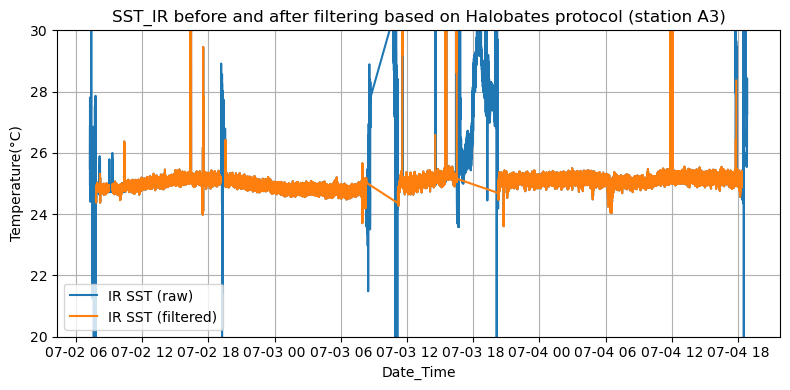

In [249]:
plt.figure(figsize=(8, 4))
plt.plot(df_sst['Time'], df_sst["SST (°C)"], label='IR SST (raw)')
plt.plot(sst_cleaned['Time'], sst_cleaned["SST (°C)"], label='IR SST (filtered)')
plt.xlabel('Date_Time')
plt.ylabel('Temperature(°C)')
plt.title(f'SST_IR before and after filtering based on Halobates protocol (station {ID})')
plt.legend(loc = "lower left")
plt.grid(True)
plt.tight_layout()

plt.ylim(20, 30)

plt.show()

#### Remove futher peaks

In [216]:
# Remove further peaks using additional filters

# Mask values outside [min_val, max_val] by setting them to NaN.
def clip_data(series: pd.Series, min_val: float, max_val: float) -> pd.Series:
    """
    Mask values outside [min_val, max_val] by setting them to NaN.
    """
    return series.where(series.between(min_val, max_val))

# Compute a symmetric Exponentially Weighted Moving Average (EWMA) by forward and backward passes.
def ewma_forward_backward(series: pd.Series, span: int) -> pd.Series:
    """
    Compute a symmetric EWMA by forward and backward passes.
    """
    fwd = series.ewm(span=span, adjust=False).mean()
    bwd = series[::-1].ewm(span=span, adjust=False).mean()[::-1]
    return (fwd + bwd) / 2

# Remove points that deviate from reference by more than delta.
def remove_delta_outliers(series: pd.Series, reference: pd.Series, delta: float) -> pd.Series:
    """
    Mask points that deviate from reference by more than delta.
    """
    return series.mask((series - reference).abs() > delta)

# Remove values beyond num_std standard deviations from the mean.
def remove_std_outliers(series: pd.Series, num_std: float) -> pd.Series:
    """
    Mask values beyond num_std standard deviations from the mean.
    """
    m, s = series.mean(), series.std()
    return series.mask((series - m).abs() > num_std * s)

In [251]:
# === Apply all functions to remove peaks
min_sst = 24  # Define a minimum SST value to clip
max_sst = 26  # Define a maximum SST value to clip

sst_removepeaks = sst_cleaned.copy()
sst_removepeaks['y_clipped']       = clip_data(sst_removepeaks['SST (\u00b0C)'], min_sst, max_sst)
sst_removepeaks['y_ewma_fb']       = ewma_forward_backward(sst_removepeaks['y_clipped'], span=100)
sst_removepeaks['y_no_delta']      = remove_delta_outliers(sst_removepeaks['y_clipped'], sst_removepeaks['y_ewma_fb'], delta=0.5)
sst_removepeaks['y_no_peaks']      = remove_std_outliers(sst_removepeaks['y_no_delta'], num_std=3)

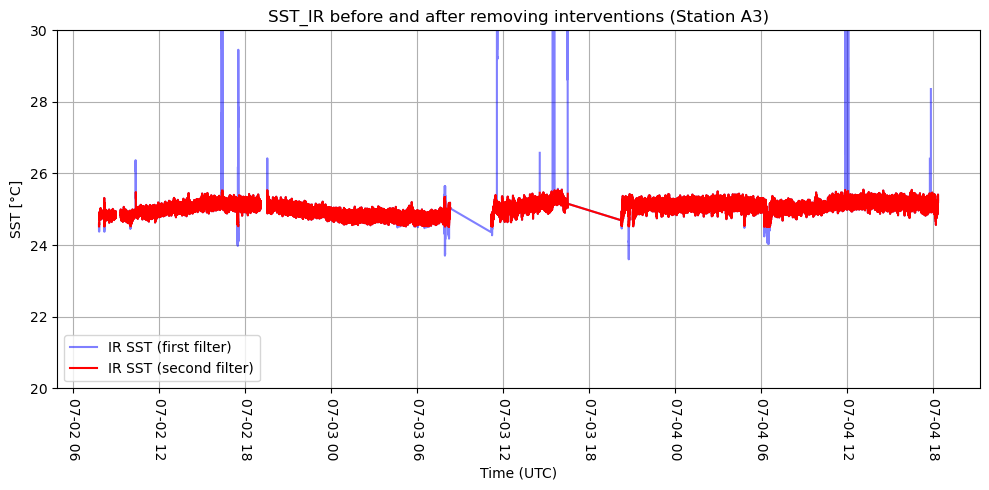

In [252]:
# PLOT
plt.figure(figsize=(10, 5))
plt.plot(sst_removepeaks["Time"], sst_removepeaks["SST (°C)"], alpha=0.5, label='IR SST (first filter)', color='blue')
plt.plot(sst_removepeaks["Time"], sst_removepeaks['y_no_peaks'], label='IR SST (second filter)', color='red')


plt.xlabel("Time (UTC)")
plt.ylabel("SST [°C]")
plt.title(f"SST_IR before and after removing interventions (Station {ID})")
plt.xticks(rotation=-90)

plt.ylim(20, 30)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Compare with Halobates SML temperature

In [189]:
# Apply same filtering based on Halobates protocol to Habolates SML temperature -> this we don't really need as H
# keeps measuring also during intervention times
#halo_sml_temp = clean_sst(df_halo, df_protocol, sst_variable="CTD_Temp_SML", shift_s=300)

df_halo['Time'] = pd.to_datetime(df_halo['Time'])
df_temp = df_halo.set_index('Time').sort_index()

#IMP: Halobates dataset does not have seconds in the time (for some weird reason), so for each minute
# there are 60 measurements. Need to add seconds manually

# 1) Parse the minute‐only timestamp in df_halo
df_halo['Time'] = pd.to_datetime(df_halo['Time'], format='%Y-%m-%d %H:%M')

# 2) Within each minute, assign a 0–59 seconds offset
df_halo['second'] = df_halo.groupby('Time').cumcount()

# 3) Add that offset to build full per‐second timestamps
df_halo['Time'] = df_halo['Time'] + pd.to_timedelta(df_halo['second'], unit='s')

# 4) Drop the helper column
df_halo = df_halo.drop(columns=['second'])

print(df_halo['Time'].head())
print("\nAdded seconds to Halobates timestamps.")


0   2025-06-29 07:00:00
1   2025-06-29 07:00:01
2   2025-06-29 07:00:02
3   2025-06-29 07:00:03
4   2025-06-29 07:00:04
Name: Time, dtype: datetime64[ns]

Added seconds to Halobates timestamps.


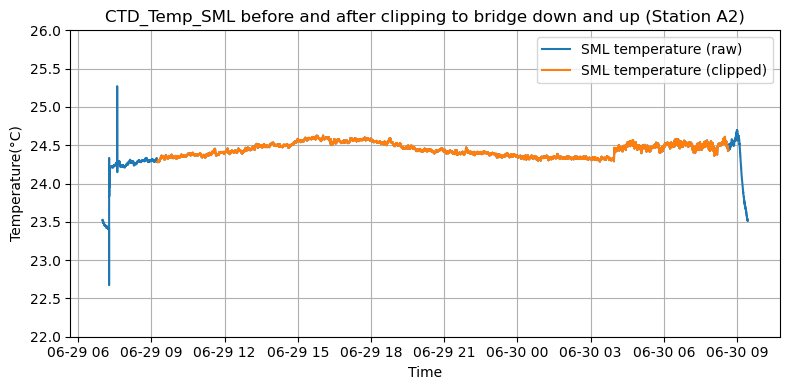

In [190]:
#Clip Halobates data to IR camera data
non_na = sst_removepeaks.dropna(subset=['y_no_peaks'])
start_time = non_na['Time'].min()
end_time   = non_na['Time'].max()


mask = (df_halo['Time'] >= start_time) & (df_halo['Time'] <= end_time)
df_halo_clipped = df_halo.loc[mask].copy()
df_halo_clipped.reset_index(drop=True, inplace=True)

# Remove first and last Nans from SST data as well 
mask2 = (sst_removepeaks['Time'] >= start_time) & (sst_removepeaks['Time'] <= end_time)
sst_cleaned_clipped = sst_removepeaks.loc[mask2].copy()
sst_cleaned_clipped.reset_index(drop=True, inplace=True)

plt.figure(figsize=(8, 4))
plt.plot(df_halo['Time'], df_halo["CTD_Temp_SML"], label='SML temperature (raw)')
plt.plot(df_halo_clipped['Time'], df_halo_clipped['CTD_Temp_SML'], label='SML temperature (clipped)')
plt.xlabel('Time')
plt.ylabel('Temperature(°C)')
plt.title(f'CTD_Temp_SML before and after clipping to bridge down and up (Station {ID})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(22, 26)
plt.show()

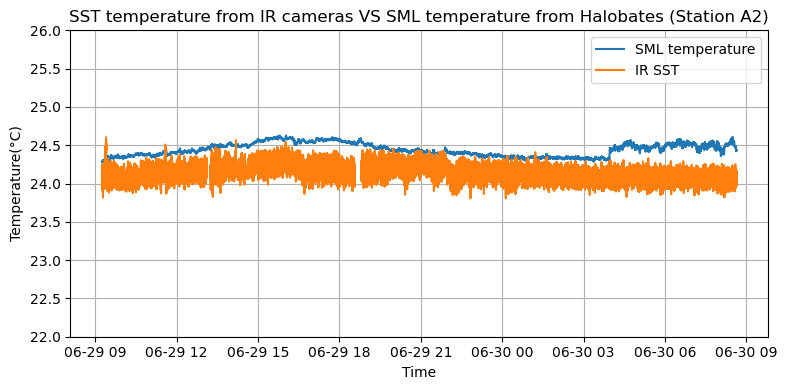

In [192]:
# Compare Halobates SML temperature with SST after removing peaks

plt.figure(figsize=(8, 4))
plt.plot(df_halo_clipped['Time'], df_halo_clipped['CTD_Temp_SML'], label='SML temperature')
plt.plot(sst_cleaned_clipped['Time'], sst_cleaned_clipped["y_no_peaks"], label='IR SST')
plt.xlabel('Time')
plt.ylabel('Temperature(°C)')
plt.title(f'SST temperature from IR cameras VS SML temperature from Halobates (Station {ID})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(22, 26)
plt.show()


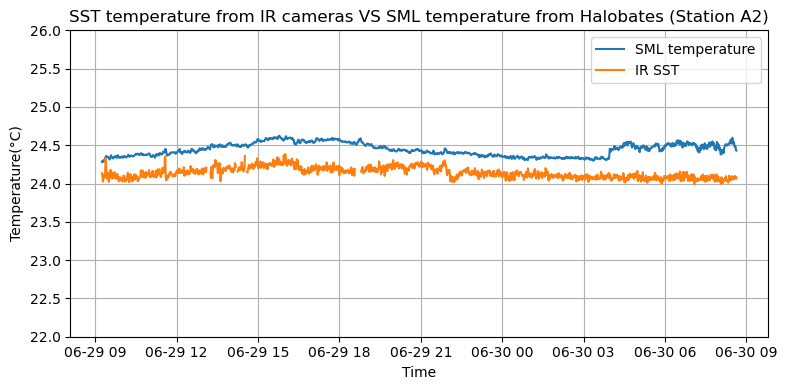

In [193]:
# Calculate 1 minute averages
sst_cleaned_avg = sst_cleaned_clipped.set_index('Time').resample('1min').mean().reset_index()
df_halo_avg = df_halo_clipped.set_index('Time').resample('1min').mean().reset_index()


plt.figure(figsize=(8, 4))
plt.plot(df_halo_avg['Time'], df_halo_avg['CTD_Temp_SML'], label='SML temperature')
plt.plot(sst_cleaned_avg['Time'], sst_cleaned_avg["y_no_peaks"], label='IR SST')
plt.xlabel('Time')
plt.ylabel('Temperature(°C)')
plt.title(f'SST temperature from IR cameras VS SML temperature from Halobates (Station {ID})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(22, 26)
plt.show()


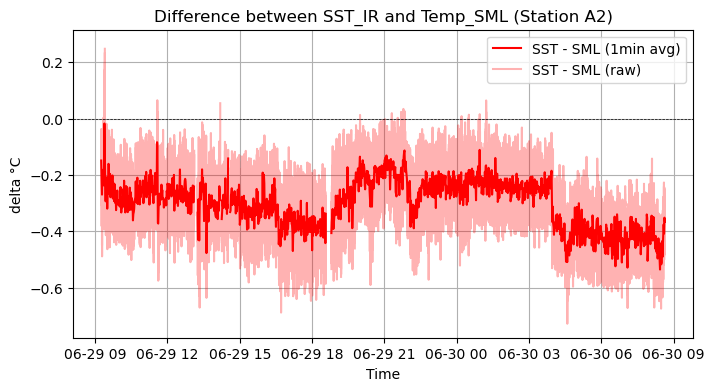

In [194]:
# Compute difference between SST and SML temperature both 1min average and raw
diff_avg = sst_cleaned_avg["y_no_peaks"] - df_halo_avg["CTD_Temp_SML"]
diff = sst_cleaned_clipped["y_no_peaks"] - df_halo_clipped["CTD_Temp_SML"]

plt.figure(figsize=(8, 4))
plt.plot(sst_cleaned_avg['Time'], diff_avg, label='SST - SML (1min avg)', color='red')
plt.plot(sst_cleaned_clipped['Time'], diff, label='SST - SML (raw)', color='red', alpha=0.3)
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)

plt.xlabel('Time')
plt.ylabel('delta °C')
plt.title(f'Difference between SST_IR and Temp_SML (Station {ID})')

plt.grid(True)
plt.legend()
plt.show()


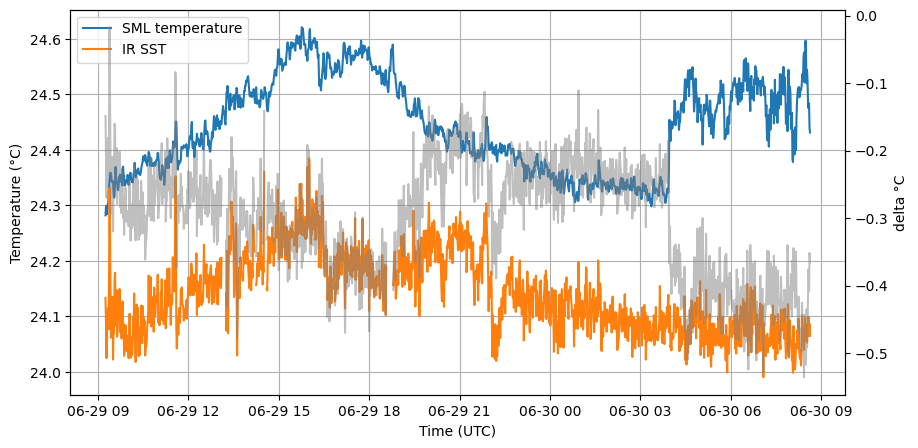

In [ ]:
# Plot together -> this is really not pretty

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_halo_avg['Time'], df_halo_avg['CTD_Temp_SML'], label='SML temperature')
ax.plot(sst_cleaned_avg['Time'], sst_cleaned_avg["y_no_peaks"], label='IR SST')
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Temperature (°C)")
ax.grid(True)
ax.legend()

ax1 = ax.twinx()
ax1.plot(sst_cleaned_avg["Time"], diff_avg, label='SST - SML (1min avg)', color='grey', alpha = 0.5)
#ax1.plot(sst_cleaned_clipped["Time"], diff, label='SST - SML (raw)', color='red', alpha=0.3)
ax1.set_ylabel("delta °C")

plt.show()




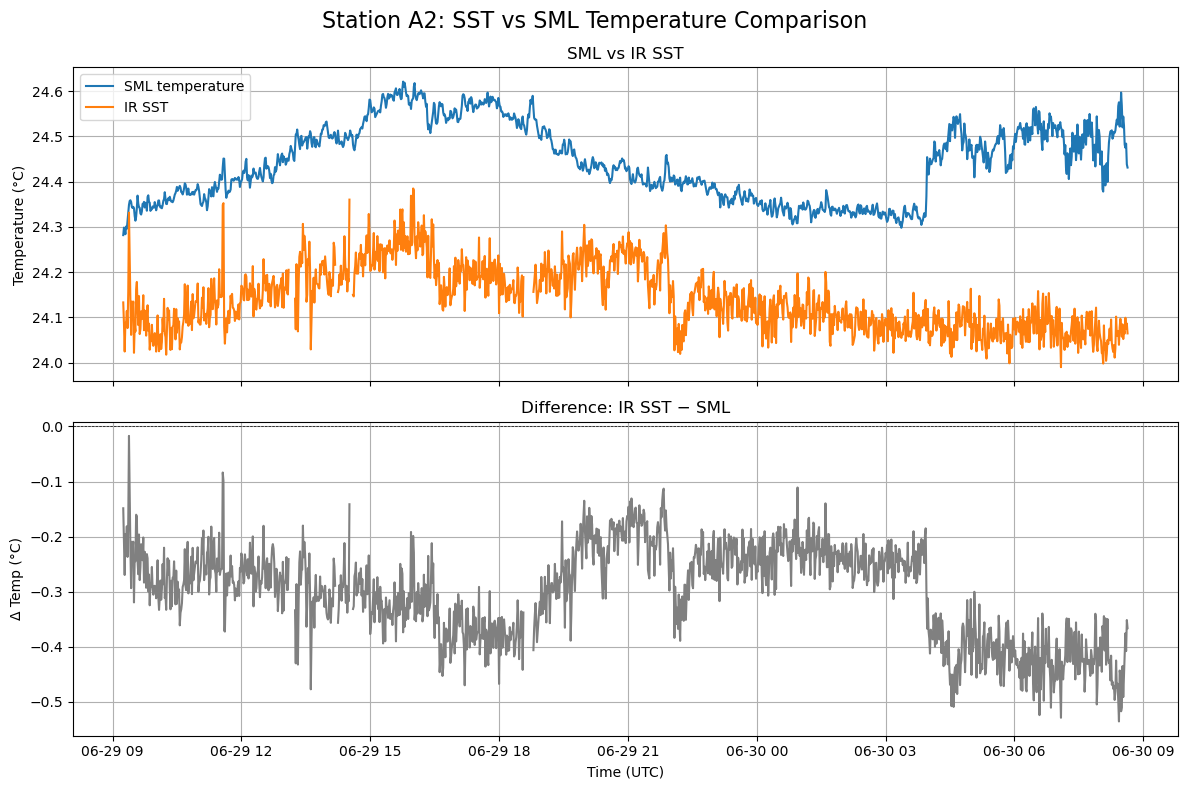

In [205]:

# Plot SST and SML temperatures together, and their difference below
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

# Top subplot: SML vs IR SST
axes[0].plot(df_halo_avg['Time'], df_halo_avg['CTD_Temp_SML'], label='SML temperature')
axes[0].plot(sst_cleaned_avg['Time'], sst_cleaned_avg['y_no_peaks'], label='IR SST')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('SML vs IR SST')
axes[0].legend()
axes[0].grid(True)

# Bottom subplot: Difference SST − SML
axes[1].plot(sst_cleaned_avg['Time'], diff_avg, label='SST − SML', color='grey')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_ylabel('Δ Temp (°C)')
axes[1].set_title('Difference: IR SST − SML')
#axes[1].legend()
axes[1].grid(True)

# Common x‑axis label
axes[1].set_xlabel('Time (UTC)')

plt.suptitle(f"Station {ID}: SST vs SML Temperature Comparison", fontsize=16)

plt.tight_layout()
plt.show()
